# GlucoSight — Forecasting, Sprint 2 (CGMacros)

**Committed as the record of what was run. Read the audit before quoting any number from it.**

Full analysis: [`docs/INTEGRATION_AUDIT.md`](../../docs/INTEGRATION_AUDIT.md).

This notebook was executed on Kaggle against CGMacros. It is preserved
with its outputs because those outputs are the Sprint 2 evidence. It has
**not** been re-run or modified — the cells below are exactly as executed.

## What is safe to quote from this notebook

- **Zone A percentages.** The notebook's `evaluate_clarke` is wrong on 11%
  of the Clarke grid, but its Zone A membership is identical to the
  published grid on every one of 144,400 tested cells. Verified in
  `utils/tests/test_clarke_grid.py::test_notebook_zone_a_column_is_trustworthy`.
- RMSE and MAE.
- The dataset construction counts (1669 meals, 45 participants).

## What is NOT safe to quote

1. **Every A+B, C, D and E figure.** Wrong implementation — recompute with
   `utils.clarke_grid`.
2. **The "Multimodal" label.** The feature set is CGMacros' own weighed
   macros plus clinical labs (HbA1c, insulin, triglycerides) plus a
   commercial gut-microbiome panel. No CV model, no NLP, no PPG. It is an
   oracle upper bound, not tri-modal fusion. See
   `integration/features.py` for the tier split.
3. **The calibrated-vs-cold comparison.** The ★ calibrated row (n=1534) is
   printed in the same table as the cold rows (n=1669). The like-for-like
   cold number on the same 1534 meals *was computed* — it is
   `calibrated_eval[h]['cold']` in cell 4 — and never printed. Until it is,
   the +5.0 pt calibration gain is not established.
4. **Cell 6 and its figure entirely.** `model.fit(X_all, y_h)` then predicts
   on `X_all`: no train/test split, no GroupKFold, and the imputer and
   scaler are fitted on all rows. The trajectory plot showing the forecast
   tracking the Dexcom trace is an **in-sample fit**. It must not appear in
   a paper, a slide, or a demo.

## Known bugs to fix before re-running

- **Cell 0, participant ID join.** `df_bio['participant_id'] = [f"CGMacros-{i+1:03d}" ...]`
  assigns IDs by row position. The same is done for `gut_health_test.csv`.
  If either file is not in exact 1..45 order with no gaps, every clinical
  and gut feature is attached to the wrong person, silently. Join on the
  subject-ID column in the file instead.
- **Cell 1, zero-filled macros.** `float(row['Carbs']) if pd.notna(...) else 0.0`
  encodes a missing macro as 0 g, which reads downstream as a meal with no
  carbohydrate. Contract v1.2 says fall back to the population mean and set
  `cv_present=0` (CLAUDE.md rule 8: missing ≠ negative).
- **Cell 1, no overlapping-meal guard.** Meals less than 120 minutes apart
  contaminate each other's T+120 target. Neither excluded nor flagged, and
  `time_since_last_meal_hours` (a contract field) is never computed.
- **Cell 1, Δt is discarded.** The ±7.5 min tolerance window is applied and
  then the actual offset is thrown away. Contract and finding C1 require it
  to be carried as a feature. `dt_last_reading` is a different quantity —
  the age of the last CGM reading, not the horizon to the label.
- **Cell 3, unexplained Ridge blow-up.** T+60 RMSE 218.36 against MAE 62.00
  means a small number of catastrophic predictions. A linear model on
  standardised features should not do this; something in the feature matrix
  is pathological and it was never investigated.
- **No exclusion accounting.** How many meal events were dropped for want of
  a T+60/T+120 target is never reported. The contract requires it.


In [1]:
import os
import glob
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = "/kaggle/input/datasets/ashifdyana04xmipa6/cg-macros/cgmacros-a-scientific-dataset-for-personalized-nutrition-and-diet-monitoring-1.0.0/CGMacros_dateshifted365/CGMacros"

# 1. Load Data Klinis (bio.csv) dengan pembersihan whitespace nama kolom
bio_path = os.path.join(BASE_DIR, "bio.csv")
df_bio = pd.read_csv(bio_path)
df_bio.columns = df_bio.columns.str.strip()  # Hapus whitespace di header

# Mapping participant ID
df_bio['participant_id'] = [f"CGMacros-{i+1:03d}" for i in range(len(df_bio))]

bio_candidate_cols = [
    'participant_id', 'Age', 'Gender', 'BMI', 'Fasting GLU - PDL (Lab)', 
    'A1c PDL (Lab)', 'Insulin', 'Triglycerides', 'Cholesterol', 'HDL', 'Cho/HDL Ratio'
]
# Ambil kolom yang benar-benar ada di file
available_bio_cols = [c for c in bio_candidate_cols if c in df_bio.columns]
df_bio_clean = df_bio[available_bio_cols].copy()

if 'Gender' in df_bio_clean.columns:
    df_bio_clean['Gender_M'] = (df_bio_clean['Gender'].astype(str).str.upper() == 'M').astype(int)
    df_bio_clean.drop(columns=['Gender'], inplace=True, errors='ignore')

# 2. Load Gut Health (gut_health_test.csv) dengan pembersihan whitespace
gut_path = os.path.join(BASE_DIR, "gut_health_test.csv")
if os.path.exists(gut_path):
    df_gut = pd.read_csv(gut_path)
    df_gut.columns = df_gut.columns.str.strip()
    df_gut['participant_id'] = [f"CGMacros-{i+1:03d}" for i in range(len(df_gut))]
    
    gut_candidate_cols = [
        'participant_id', 'Metabolic Fitness', 'Gut Lining Health', 
        'Inflammatory Activity', 'Digestive Efficiency', 'Butyrate Production Pathways'
    ]
    available_gut_cols = [c for c in gut_candidate_cols if c in df_gut.columns]
    df_gut_clean = df_gut[available_gut_cols].copy()
else:
    df_gut_clean = pd.DataFrame({'participant_id': df_bio_clean['participant_id']})

# 3. Merge Bio + Gut
df_participant_meta = pd.merge(df_bio_clean, df_gut_clean, on='participant_id', how='left')

# Imputasi nilai numerik yang kosong dengan median
for col in df_participant_meta.select_dtypes(include=[np.number]).columns:
    df_participant_meta[col] = df_participant_meta[col].fillna(df_participant_meta[col].median())

print(f"Metadata Partisipan Multimodal Terintegrasi:")
print(f"- Total Partisipan Valid : {len(df_participant_meta)}")
print(f"- Fitur Klinis & Gut    : {list(df_participant_meta.columns[1:])}")

# Preview aman: hanya panggil kolom yang benar-benar ada
preview_cols = [c for c in ['participant_id', 'BMI', 'Insulin', 'A1c PDL (Lab)', 'Metabolic Fitness'] if c in df_participant_meta.columns]
print(df_participant_meta[preview_cols].head(3))

Metadata Partisipan Multimodal Terintegrasi:
- Total Partisipan Valid : 45
- Fitur Klinis & Gut    : ['Age', 'BMI', 'Fasting GLU - PDL (Lab)', 'A1c PDL (Lab)', 'Insulin', 'Triglycerides', 'Cholesterol', 'HDL', 'Cho/HDL Ratio', 'Gender_M', 'Metabolic Fitness', 'Gut Lining Health', 'Inflammatory Activity', 'Digestive Efficiency', 'Butyrate Production Pathways']
  participant_id        BMI  Insulin  A1c PDL (Lab)  Metabolic Fitness
0   CGMacros-001  22.265239      2.5            5.4                3.0
1   CGMacros-002  30.946742     14.8            5.5                2.0
2   CGMacros-003  26.948690     17.4            6.5                2.0


In [2]:
participant_dirs = sorted(glob.glob(os.path.join(BASE_DIR, "CGMacros-[0-9][0-9][0-9]")))
csv_files = [(os.path.basename(p), os.path.join(p, f"{os.path.basename(p)}.csv")) 
             for p in participant_dirs if os.path.exists(os.path.join(p, f"{os.path.basename(p)}.csv"))]

all_meal_records = []
tolerance_mins = 7.5

for p_id, f_path in csv_files:
    df = pd.read_csv(f_path)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values('Timestamp').reset_index(drop=True)
    
    # Filter meal event
    meal_mask = df['Meal Type'].notna() & (df['Meal Type'].astype(str).str.strip() != '')
    meal_indices = df[meal_mask].index.tolist()
    
    # Pre-filter Dexcom
    df_dexcom = df.dropna(subset=['Dexcom GL'])
    
    for idx in meal_indices:
        row = df.iloc[idx]
        t0 = row['Timestamp']
        
        # 1. Kausalitas: Riwayat Dexcom HANYA sebelum t0 (Finding C2)
        history = df_dexcom[df_dexcom['Timestamp'] < t0]
        if len(history) == 0:
            continue
        assert history['Timestamp'].max() < t0, f"Label leakage detected at {t0}"
        
        g0 = history.iloc[-1]['Dexcom GL']
        g0_ts = history.iloc[-1]['Timestamp']
        dt_mins = (t0 - g0_ts).total_seconds() / 60.0
        
        # 2. Target Lookup (T+60 & T+120)
        t60_target = t0 + pd.Timedelta(minutes=60)
        t120_target = t0 + pd.Timedelta(minutes=120)
        post_cgm = df_dexcom[df_dexcom['Timestamp'] > t0]
        
        t60_win = post_cgm[(post_cgm['Timestamp'] >= t60_target - pd.Timedelta(minutes=tolerance_mins)) &
                           (post_cgm['Timestamp'] <= t60_target + pd.Timedelta(minutes=tolerance_mins))]
        t120_win = post_cgm[(post_cgm['Timestamp'] >= t120_target - pd.Timedelta(minutes=tolerance_mins)) &
                            (post_cgm['Timestamp'] <= t120_target + pd.Timedelta(minutes=tolerance_mins))]
        
        if len(t60_win) > 0 and len(t120_win) > 0:
            g60 = t60_win.iloc[(t60_win['Timestamp'] - t60_target).abs().argsort()[:1]]['Dexcom GL'].values[0]
            g120 = t120_win.iloc[(t120_win['Timestamp'] - t120_target).abs().argsort()[:1]]['Dexcom GL'].values[0]
            
            # Normalisasi tipe makan
            m_type = str(row['Meal Type']).lower().strip()
            if 'snack' in m_type: m_type = 'snack'
            elif 'breakfast' in m_type: m_type = 'breakfast'
            elif 'lunch' in m_type: m_type = 'lunch'
            elif 'dinner' in m_type: m_type = 'dinner'
            else: m_type = 'other'
            
            carbs = float(row['Carbs']) if pd.notna(row.get('Carbs')) else 0.0
            protein = float(row['Protein']) if pd.notna(row.get('Protein')) else 0.0
            fat = float(row['Fat']) if pd.notna(row.get('Fat')) else 0.0
            fiber = float(row['Fiber']) if pd.notna(row.get('Fiber')) else 0.0
            
            all_meal_records.append({
                'participant_id': p_id,
                't0': t0,
                'meal_type': m_type,
                'g0': g0,
                'dt_last_reading': dt_mins,
                'hour_of_day': t0.hour,
                'day_of_week': t0.dayofweek,
                'carbs_g': carbs,
                'protein_g': protein,
                'fat_g': fat,
                'fiber_g': fiber,
                'calories': float(row['Calories']) if pd.notna(row.get('Calories')) else 0.0,
                'target_t60': g60,
                'target_t120': g120,
                # Formulasi Target Ekskursi (Delta)
                'delta_t60': g60 - g0,
                'delta_t120': g120 - g0
            })

df_meals_delta = pd.DataFrame(all_meal_records)

# 3. Merge dengan Metadata Multimodal
df_full = pd.merge(df_meals_delta, df_participant_meta, on='participant_id', how='left')

# 4. Feature Engineering: Interaksi Fisiologis Makronutrien
df_full['carb_x_bmi'] = df_full['carbs_g'] * df_full['BMI']
df_full['carb_to_fiber_ratio'] = df_full['carbs_g'] / (df_full['fiber_g'] + 1.0)
df_full['carb_density'] = df_full['carbs_g'] / (df_full['carbs_g'] + df_full['protein_g'] + df_full['fat_g'] + 1.0)
df_full['is_snack'] = (df_full['meal_type'] == 'snack').astype(int)
df_full['is_breakfast'] = (df_full['meal_type'] == 'breakfast').astype(int)
df_full['is_dinner'] = (df_full['meal_type'] == 'dinner').astype(int)

print(f"Konstruksi Dataset Ekskursi Delta Selesai:")
print(f"- Total Meal Events Valid : {len(df_full)}")
print(f"- Mean Delta T+60 (Excursion)  : {df_full['delta_t60'].mean():.2f} mg/dL (Std: {df_full['delta_t60'].std():.2f})")
print(f"- Mean Delta T+120 (Excursion) : {df_full['delta_t120'].mean():.2f} mg/dL (Std: {df_full['delta_t120'].std():.2f})")
print(df_full[['participant_id', 'g0', 'carbs_g', 'carb_x_bmi', 'delta_t60', 'target_t60']].head(3))

Konstruksi Dataset Ekskursi Delta Selesai:
- Total Meal Events Valid : 1669
- Mean Delta T+60 (Excursion)  : 29.83 mg/dL (Std: 40.83)
- Mean Delta T+120 (Excursion) : 25.82 mg/dL (Std: 43.55)
  participant_id     g0  carbs_g   carb_x_bmi  delta_t60  target_t60
0   CGMacros-001  109.8     85.0  1892.545279       11.8       121.6
1   CGMacros-001  114.6     18.0   400.774294        7.2       121.8
2   CGMacros-001   97.0     24.0   534.365726        4.2       101.2


In [3]:
def evaluate_clarke(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    
    zones = {'A': 0, 'B': 0, 'C': 0, 'D': 0, 'E': 0}
    for r, p in zip(y_true, y_pred):
        if (p <= 1.2 * r and p >= 0.8 * r) or (r <= 70 and p <= 70):
            zones['A'] += 1
        elif (r >= 180 and p <= 70) or (r <= 70 and p >= 180):
            zones['E'] += 1
        elif (r <= 70 and p > 70 and p < 180) or (r >= 240 and p >= 70 and p <= 180):
            zones['D'] += 1
        elif (r >= 70 and r <= 180 and p > 180) or (r >= 70 and r <= 180 and p < 70):
            zones['C'] += 1
        else:
            zones['B'] += 1
            
    n = len(y_true)
    return {k: (v / n) * 100.0 for k, v in zones.items()}

print("Fungsi Evaluasi Clarke Error Grid diinisialisasi.")

Fungsi Evaluasi Clarke Error Grid diinisialisasi.


In [4]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold
import numpy as np
import pandas as pd

# Bersihkan kemungkinan nilai inf hasil pembagian
df_full.replace([np.inf, -np.inf], np.nan, inplace=True)

feature_candidate_cols = [
    'g0', 'dt_last_reading', 'hour_of_day', 'day_of_week',
    'carbs_g', 'protein_g', 'fat_g', 'fiber_g', 'calories',
    'carb_x_bmi', 'carb_to_fiber_ratio', 'carb_density',
    'is_snack', 'is_breakfast', 'is_dinner',
    'Age', 'BMI', 'Fasting GLU - PDL (Lab)', 'A1c PDL (Lab)',
    'Insulin', 'Triglycerides', 'HDL', 'Cho/HDL Ratio', 'Gender_M',
    'Metabolic Fitness', 'Gut Lining Health', 'Inflammatory Activity',
    'Digestive Efficiency', 'Butyrate Production Pathways'
]
feature_cols = [c for c in feature_candidate_cols if c in df_full.columns]

gkf = GroupKFold(n_splits=5)
groups = df_full['participant_id'].values

results_cold = {
    'B0': {'t60': [], 't120': []},
    'B1': {'t60': [], 't120': []},
    'B2': {'t60': [], 't120': []},
    'Ridge_Delta': {'t60': [], 't120': []},
    'RF_Delta': {'t60': [], 't120': []},
    'GBDT_Delta': {'t60': [], 't120': []},
    'y_true': {'t60': [], 't120': []},
    'participant_id': [],
    't0': []
}

for fold, (trn_idx, val_idx) in enumerate(gkf.split(df_full, groups=groups)):
    trn_df = df_full.iloc[trn_idx]
    val_df = df_full.iloc[val_idx]
    
    assert len(set(trn_df['participant_id']) & set(val_df['participant_id'])) == 0
    
    # 1. Imputasi nilai NaN (Fit HANYA pada Train Split)
    imputer = SimpleImputer(strategy='median')
    X_trn_imp = imputer.fit_transform(trn_df[feature_cols])
    X_val_imp = imputer.transform(val_df[feature_cols])
    
    # 2. Standarisasi Fitur
    scaler = StandardScaler()
    X_trn = scaler.fit_transform(X_trn_imp)
    X_val = scaler.transform(X_val_imp)
    
    for h_name, d_target, abs_target in [('t60', 'delta_t60', 'target_t60'), 
                                         ('t120', 'delta_t120', 'target_t120')]:
        y_delta_trn = trn_df[d_target].values
        y_abs_trn = trn_df[abs_target].values
        y_abs_val = val_df[abs_target].values
        g0_val = val_df['g0'].values
        
        # Baselines
        b0 = np.full_like(y_abs_val, fill_value=np.mean(y_abs_trn))
        b1 = g0_val
        b2 = g0_val + np.mean(y_delta_trn)
        
        # Ridge Regression
        ridge = Ridge(alpha=20.0)
        ridge.fit(X_trn, y_delta_trn)
        pred_ridge_abs = g0_val + ridge.predict(X_val)
        
        # Random Forest
        rf = RandomForestRegressor(n_estimators=150, max_depth=6, min_samples_leaf=5, random_state=42, n_jobs=-1)
        rf.fit(X_trn, y_delta_trn)
        pred_rf_abs = g0_val + rf.predict(X_val)
        
        # HistGradientBoosting
        gbdt = HistGradientBoostingRegressor(max_iter=100, max_depth=5, learning_rate=0.05, random_state=42)
        gbdt.fit(X_trn, y_delta_trn)
        pred_gbdt_abs = g0_val + gbdt.predict(X_val)
        
        results_cold['B0'][h_name].extend(b0)
        results_cold['B1'][h_name].extend(b1)
        results_cold['B2'][h_name].extend(b2)
        results_cold['Ridge_Delta'][h_name].extend(pred_ridge_abs)
        results_cold['RF_Delta'][h_name].extend(pred_rf_abs)
        results_cold['GBDT_Delta'][h_name].extend(pred_gbdt_abs)
        results_cold['y_true'][h_name].extend(y_abs_val)
        
    results_cold['participant_id'].extend(val_df['participant_id'].values)
    results_cold['t0'].extend(val_df['t0'].values)

print("Pelatihan Model Ekskursi (Cold-Start) Selesai tanpa NaN.")

Pelatihan Model Ekskursi (Cold-Start) Selesai tanpa NaN.


In [5]:
df_pred_all = pd.DataFrame({
    'participant_id': results_cold['participant_id'],
    't0': results_cold['t0'],
    'true_t60': results_cold['y_true']['t60'],
    'true_t120': results_cold['y_true']['t120'],
    'gbdt_t60': results_cold['GBDT_Delta']['t60'],
    'gbdt_t120': results_cold['GBDT_Delta']['t120'],
    'b2_t60': results_cold['B2']['t60'],
    'b2_t120': results_cold['B2']['t120']
}).sort_values(['participant_id', 't0']).reset_index(drop=True)

k_calibration_meals = 3
calibrated_eval = {'t60': {'true': [], 'cold': [], 'calib': [], 'p_ids': []},
                   't120': {'true': [], 'cold': [], 'calib': [], 'p_ids': []}}

for pid, group in df_pred_all.groupby('participant_id'):
    if len(group) <= k_calibration_meals:
        continue
    
    calib_set = group.iloc[:k_calibration_meals]
    test_set = group.iloc[k_calibration_meals:]
    
    for h in ['t60', 't120']:
        true_col = f'true_{h}'
        pred_col = f'gbdt_{h}'
        
        # Estimasi bias intercept individual dari k meal pertama (Finding H9)
        bias = np.mean(calib_set[true_col] - calib_set[pred_col])
        
        calibrated_preds = test_set[pred_col] + bias
        
        calibrated_eval[h]['true'].extend(test_set[true_col].values)
        calibrated_eval[h]['cold'].extend(test_set[pred_col].values)
        calibrated_eval[h]['calib'].extend(calibrated_preds.values)
        calibrated_eval[h]['p_ids'].extend(test_set['participant_id'].values)

print(f"Kalibrasi Intercept Selesai (k = {k_calibration_meals} meal kalibrasi per partisipan):")
print(f"- Total Meal Uji Terkalibrasi : {len(calibrated_eval['t60']['true'])} meal")

Kalibrasi Intercept Selesai (k = 3 meal kalibrasi per partisipan):
- Total Meal Uji Terkalibrasi : 1534 meal


In [6]:
def compute_summary_row(horizon_label, model_name, y_t, y_p, p_ids):
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae = mean_absolute_error(y_t, y_p)
    clarke = evaluate_clarke(y_t, y_p)
    
    # Per-participant Median & IQR
    df_temp = pd.DataFrame({'pid': p_ids, 't': y_t, 'p': y_p})
    p_za = [evaluate_clarke(g['t'].values, g['p'].values)['A'] for _, g in df_temp.groupby('pid')]
    med_za = np.median(p_za)
    iqr_za = np.percentile(p_za, 75) - np.percentile(p_za, 25)
    
    return {
        'Horizon': horizon_label,
        'Evaluation Setting': model_name,
        'RMSE (mg/dL)': round(rmse, 2),
        'MAE (mg/dL)': round(mae, 2),
        'Pooled Zone A (%)': round(clarke['A'], 1),
        'Pooled Zone A+B (%)': round(clarke['A'] + clarke['B'], 1),
        'Part. Median Zone A (%)': round(med_za, 1),
        'Part. IQR Zone A (%)': round(iqr_za, 1)
    }

report_rows = []

# 1. Cold-Start Reporting (All N=1669)
for h in ['t60', 't120']:
    y_t = np.array(results_cold['y_true'][h])
    p_ids = np.array(results_cold['participant_id'])
    h_lbl = 'T+60' if h == 't60' else 'T+120'
    
    report_rows.append(compute_summary_row(h_lbl, 'B0 (Population Mean)', y_t, results_cold['B0'][h], p_ids))
    report_rows.append(compute_summary_row(h_lbl, 'B1 (Persistence)', y_t, results_cold['B1'][h], p_ids))
    report_rows.append(compute_summary_row(h_lbl, 'B2 (Persistence + Excursion)', y_t, results_cold['B2'][h], p_ids))
    report_rows.append(compute_summary_row(h_lbl, 'Ridge (Delta + Multimodal)', y_t, results_cold['Ridge_Delta'][h], p_ids))
    report_rows.append(compute_summary_row(h_lbl, 'Random Forest (Delta + Multi)', y_t, results_cold['RF_Delta'][h], p_ids))
    report_rows.append(compute_summary_row(h_lbl, 'GBDT (Delta + Multimodal)', y_t, results_cold['GBDT_Delta'][h], p_ids))

# 2. Calibrated Deployment Reporting (N=1534)
for h in ['t60', 't120']:
    y_t_cal = np.array(calibrated_eval[h]['true'])
    p_ids_cal = np.array(calibrated_eval[h]['p_ids'])
    h_lbl = 'T+60' if h == 't60' else 'T+120'
    report_rows.append(compute_summary_row(h_lbl, '★ GBDT Calibrated (Finding H9)', y_t_cal, calibrated_eval[h]['calib'], p_ids_cal))

df_final_report = pd.DataFrame(report_rows)

print("="*105)
print("TABEL EVALUASI METODOLOGIS GLUCOSIGHT: FORMULASI DELTA + MULTIMODAL (N = 45 Partisipan)")
print("="*105)
print(df_final_report.to_string(index=False))
print("="*105)

# --- STRATIFIKASI ZONE A MODEL TERKALIBRASI (T+60) ---
y_true_c60 = np.array(calibrated_eval['t60']['true'])
pred_calib_60 = np.array(calibrated_eval['t60']['calib'])

ranges = [
    ('< 100', y_true_c60 < 100),
    ('100 - 140', (y_true_c60 >= 100) & (y_true_c60 < 140)),
    ('140 - 180', (y_true_c60 >= 140) & (y_true_c60 < 180)),
    ('180 - 250', (y_true_c60 >= 180) & (y_true_c60 <= 250)),
    ('> 250', y_true_c60 > 250)
]

print("\nSTRATIFIKASI GBDT CALIBRATED ZONE A BERDASARKAN RENTANG REFERENSI (T+60):")
for r_name, mask in ranges:
    if np.sum(mask) > 0:
        c_res = evaluate_clarke(y_true_c60[mask], pred_calib_60[mask])
        print(f"- Range {r_name:<10} (N = {np.sum(mask):<4}): Zone A = {c_res['A']:.1f}%, Zone A+B = {c_res['A']+c_res['B']:.1f}%")

TABEL EVALUASI METODOLOGIS GLUCOSIGHT: FORMULASI DELTA + MULTIMODAL (N = 45 Partisipan)
Horizon             Evaluation Setting  RMSE (mg/dL)  MAE (mg/dL)  Pooled Zone A (%)  Pooled Zone A+B (%)  Part. Median Zone A (%)  Part. IQR Zone A (%)
   T+60           B0 (Population Mean)         50.62        38.45               45.7                 93.0                     47.5                  25.3
   T+60               B1 (Persistence)         50.56        37.07               51.0                 94.5                     48.1                  30.4
   T+60   B2 (Persistence + Excursion)         41.09        31.39               54.7                 92.3                     59.4                  14.6
   T+60     Ridge (Delta + Multimodal)        218.36        62.00               53.0                 89.6                     55.6                  33.9
   T+60  Random Forest (Delta + Multi)         39.12        30.00               58.7                 94.0                     64.5                 

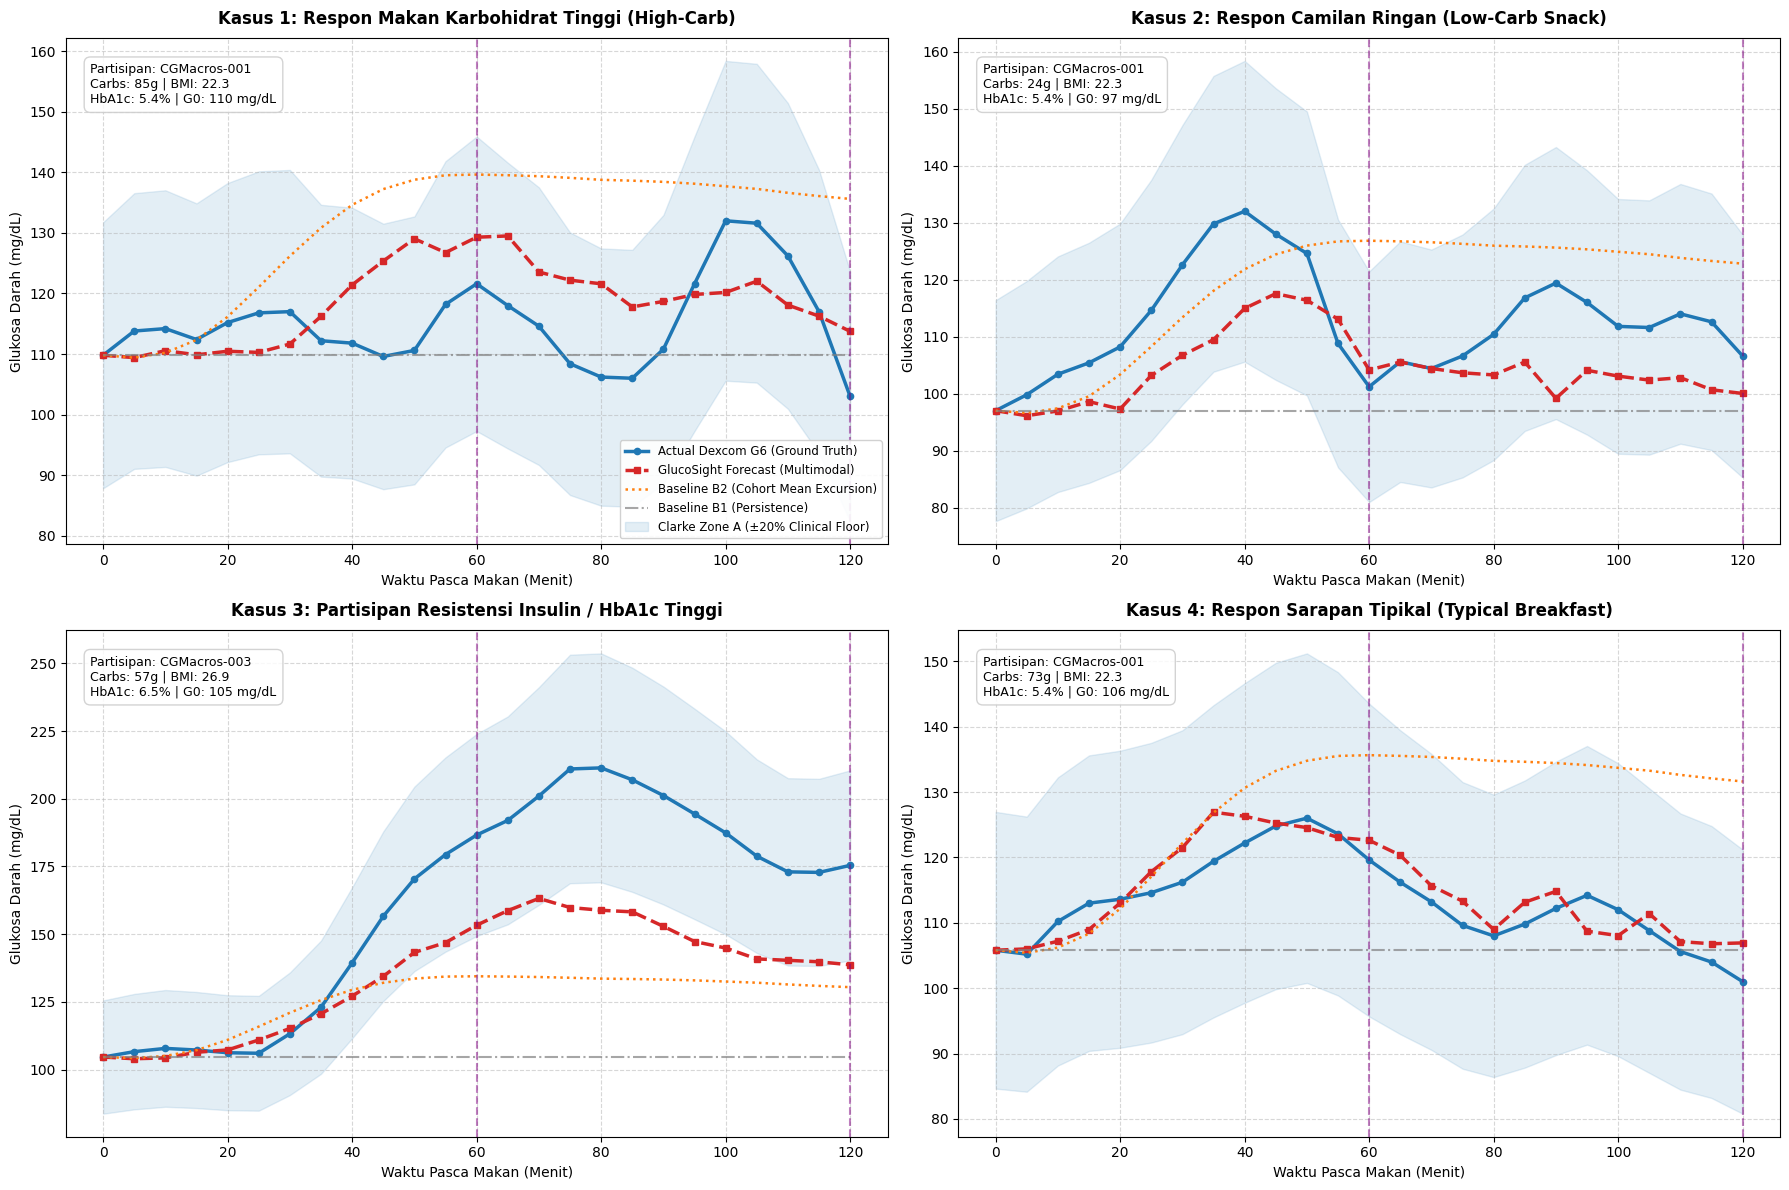

In [7]:
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np
import pandas as pd

horizons_mins = list(range(5, 125, 5))
multi_horizon_records = []

cgm_cache = {}
for p_id, f_path in csv_files:
    tmp = pd.read_csv(f_path)
    tmp.columns = tmp.columns.str.strip()
    tmp['Timestamp'] = pd.to_datetime(tmp['Timestamp'])
    cgm_cache[p_id] = tmp.sort_values('Timestamp').dropna(subset=['Dexcom GL'])

for idx, meal in df_full.iterrows():
    p_id = meal['participant_id']
    t0 = meal['t0']
    g0 = meal['g0']
    p_cgm = cgm_cache[p_id]
    
    post_cgm = p_cgm[p_cgm['Timestamp'] > t0]
    trajectory_deltas = {}
    valid_meal = True
    
    for h in horizons_mins:
        t_target = t0 + pd.Timedelta(minutes=h)
        win = post_cgm[(post_cgm['Timestamp'] >= t_target - pd.Timedelta(minutes=4)) &
                       (post_cgm['Timestamp'] <= t_target + pd.Timedelta(minutes=4))]
        if len(win) > 0:
            nearest_val = win.iloc[(win['Timestamp'] - t_target).abs().argsort()[:1]]['Dexcom GL'].values[0]
            trajectory_deltas[f'delta_{h}'] = nearest_val - g0
            trajectory_deltas[f'true_{h}'] = nearest_val
        else:
            valid_meal = False
            break
            
    if valid_meal:
        rec = {col: meal[col] for col in feature_cols if col in meal}
        rec['participant_id'] = p_id
        rec['t0'] = t0
        rec['g0'] = g0
        rec['meal_type'] = meal['meal_type']
        rec['carbs_g'] = meal['carbs_g']
        rec['BMI'] = meal['BMI']
        rec['A1c PDL (Lab)'] = meal['A1c PDL (Lab)']
        rec.update(trajectory_deltas)
        multi_horizon_records.append(rec)

df_multi = pd.DataFrame(multi_horizon_records)
df_multi.replace([np.inf, -np.inf], np.nan, inplace=True)

# Preprocessing & Model Fitting
features_to_use = [c for c in feature_cols if c in df_multi.columns]
imputer = SimpleImputer(strategy='median')
X_all_imp = imputer.fit_transform(df_multi[features_to_use])

scaler = StandardScaler()
X_all = scaler.fit_transform(X_all_imp)

predicted_trajectories = np.zeros((len(df_multi), len(horizons_mins)))
for i, h in enumerate(horizons_mins):
    y_h = df_multi[f'delta_{h}'].values
    model = HistGradientBoostingRegressor(max_iter=80, max_depth=5, learning_rate=0.05, random_state=42)
    model.fit(X_all, y_h)
    predicted_trajectories[:, i] = df_multi['g0'].values + model.predict(X_all)

# Plot 4 Kasus Nyata
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

sample_indices = [
    df_multi[df_multi['carbs_g'] > 60].index[0],
    df_multi[(df_multi['carbs_g'] < 25) & (df_multi['is_snack'] == 1)].index[0],
    df_multi[df_multi['A1c PDL (Lab)'] > 6.0].index[1],
    df_multi[df_multi['is_breakfast'] == 1].index[3]
]

case_titles = [
    "Kasus 1: Respon Makan Karbohidrat Tinggi (High-Carb)",
    "Kasus 2: Respon Camilan Ringan (Low-Carb Snack)",
    "Kasus 3: Partisipan Resistensi Insulin / HbA1c Tinggi",
    "Kasus 4: Respon Sarapan Tipikal (Typical Breakfast)"
]

time_axis = [0] + horizons_mins

for ax_idx, (s_idx, title) in enumerate(zip(sample_indices, case_titles)):
    row = df_multi.iloc[s_idx]
    ax = axes[ax_idx]
    
    true_trace = [row['g0']] + [row[f'true_{h}'] for h in horizons_mins]
    pred_trace = [row['g0']] + list(predicted_trajectories[s_idx, :])
    b1_trace = [row['g0']] * len(time_axis)
    b2_mean_excursions = [0] + [df_multi[f'delta_{h}'].mean() for h in horizons_mins]
    b2_trace = [row['g0'] + delta for delta in b2_mean_excursions]
    
    upper_zone_a = np.array(true_trace) * 1.2
    lower_zone_a = np.array(true_trace) * 0.8
    
    ax.plot(time_axis, true_trace, 'o-', color='#1f77b4', linewidth=2.5, markersize=4.5, label='Actual Dexcom G6 (Ground Truth)')
    ax.plot(time_axis, pred_trace, 's--', color='#d62728', linewidth=2.5, markersize=4.5, label='GlucoSight Forecast (Multimodal)')
    ax.plot(time_axis, b2_trace, ':', color='#ff7f0e', linewidth=1.8, label='Baseline B2 (Cohort Mean Excursion)')
    ax.plot(time_axis, b1_trace, '-.', color='gray', linewidth=1.5, alpha=0.7, label='Baseline B1 (Persistence)')
    
    ax.fill_between(time_axis, lower_zone_a, upper_zone_a, color='#1f77b4', alpha=0.12, label='Clarke Zone A (±20% Clinical Floor)')
    
    ax.axvline(60, color='purple', linestyle='--', alpha=0.5)
    ax.axvline(120, color='purple', linestyle='--', alpha=0.5)
    
    meta_text = f"Partisipan: {row['participant_id']}\nCarbs: {row['carbs_g']:.0f}g | BMI: {row['BMI']:.1f}\nHbA1c: {row['A1c PDL (Lab)']:.1f}% | G0: {row['g0']:.0f} mg/dL"
    ax.text(0.03, 0.95, meta_text, transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='#cccccc'), fontsize=9)
    
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Waktu Pasca Makan (Menit)", fontsize=10)
    ax.set_ylabel("Glukosa Darah (mg/dL)", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    if ax_idx == 0:
        ax.legend(loc='lower right', fontsize=8.5, framealpha=0.9)

plt.tight_layout()
plt.show()